<a href="https://colab.research.google.com/github/shaify-cloud/ai-mentor-portfolio/blob/main/Day7_RAG_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q chromadb sentence-transformers scikit-learn matplotlib

from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient

# Free, local, 384-dim embeddings
embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print('Embedding dim:', embed.get_sentence_embedding_dimension())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dim: 384


/tmp/ipykernel_5421/1158961417.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('Embedding dim:', embed.get_sentence_embedding_dimension())


In [ ]:
with open('../content/sample_data/cse_sem5.txt') as f:
    text = f.read()

# Split on blank lines into paragraphs
paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()][:10]

print(f'Loaded {len(paragraphs)} paragraphs')
for i, p in enumerate(paragraphs):
    print(f'  [{i+1}] {p[:80]}')

Loaded 7 paragraphs
  [1] CSE Semester 5 — Syllabus Excerpt
  [2] Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF
  [3] Database Management Systems:
ER model, relational model, normalisation (1NF thro
  [4] Computer Networks:
OSI and TCP/IP models. Physical, data link, network, transpor
  [5] Software Engineering:
SDLC models: waterfall, agile, scrum.
Requirements enginee
  [6] Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [7] Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit


In [ ]:
client = PersistentClient(path='./chroma_db')
col = client.get_or_create_collection('hello_syllabus')

# Embed all 10 paragraphs
vectors = embed.encode(paragraphs).tolist()

# Add to collection (with sequential IDs)
col.add(
    documents=paragraphs,
    embeddings=vectors,
    ids=[f'p{i}' for i in range(len(paragraphs))]
)

print(f'Indexed {col.count()} documents')

Indexed 7 documents


In [ ]:
queries = [
    'what is dynamic programming?',
    'machine learning topics',
    'operating system processes',
]

for q in queries:
    print(f'\nQuery: {q}')
    qv = embed.encode([q]).tolist()
    results = col.query(query_embeddings=qv, n_results=3)
    docs = results['documents'][0]
    distances = results['distances'][0]
    for j, (d, dist) in enumerate(zip(docs, distances)):
        print(f'  [{j+1}] (dist={dist:.3f}) {d[:80]}')


Query: what is dynamic programming?
  [1] (dist=1.464) Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [2] (dist=1.469) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit
  [3] (dist=1.476) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF

Query: machine learning topics
  [1] (dist=1.300) Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [2] (dist=1.526) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit
  [3] (dist=1.533) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF

Query: operating system processes
  [1] (dist=0.713) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF
  [2] (dist=1.246) Database Management Systems:
ER model, relational model, normalisation (1NF thro
  [3] (dist=1.370) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hos

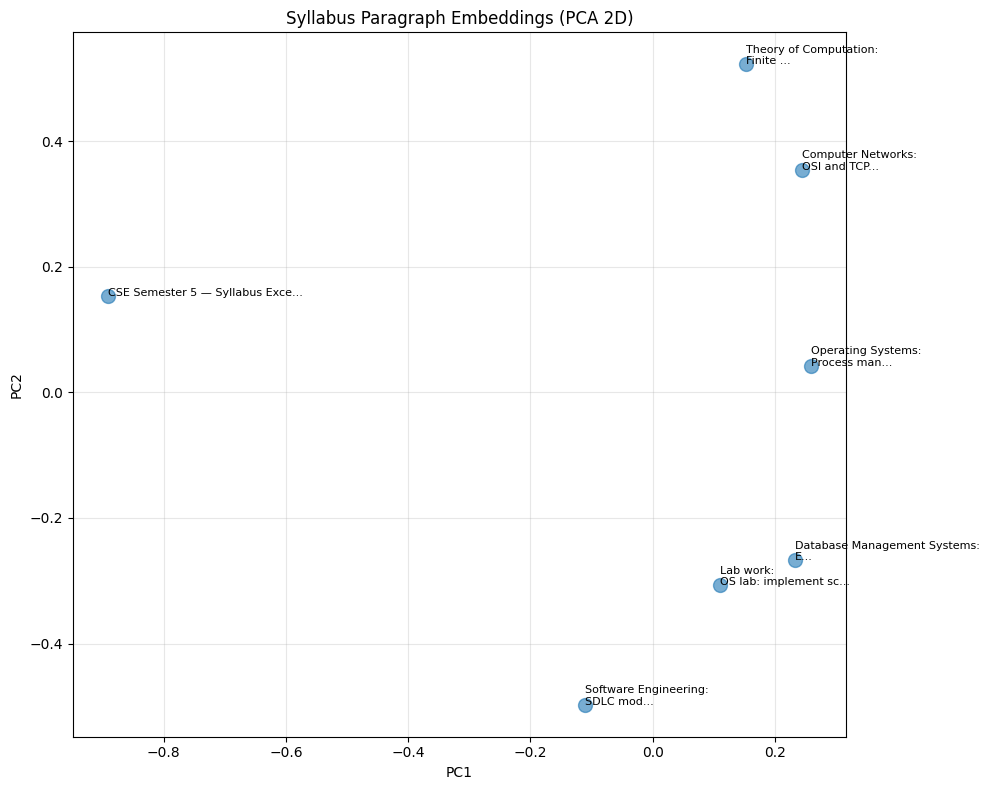

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

vectors_arr = np.array(vectors)

pca = PCA(n_components=2)
xy = pca.fit_transform(vectors_arr)

plt.figure(figsize=(10, 8))
plt.scatter(xy[:, 0], xy[:, 1], s=100, alpha=0.6)
for i, p in enumerate(paragraphs):
    label = p[:30] + '...' if len(p) > 30 else p
    plt.annotate(label, (xy[i, 0], xy[i, 1]), fontsize=8)
plt.title('Syllabus Paragraph Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

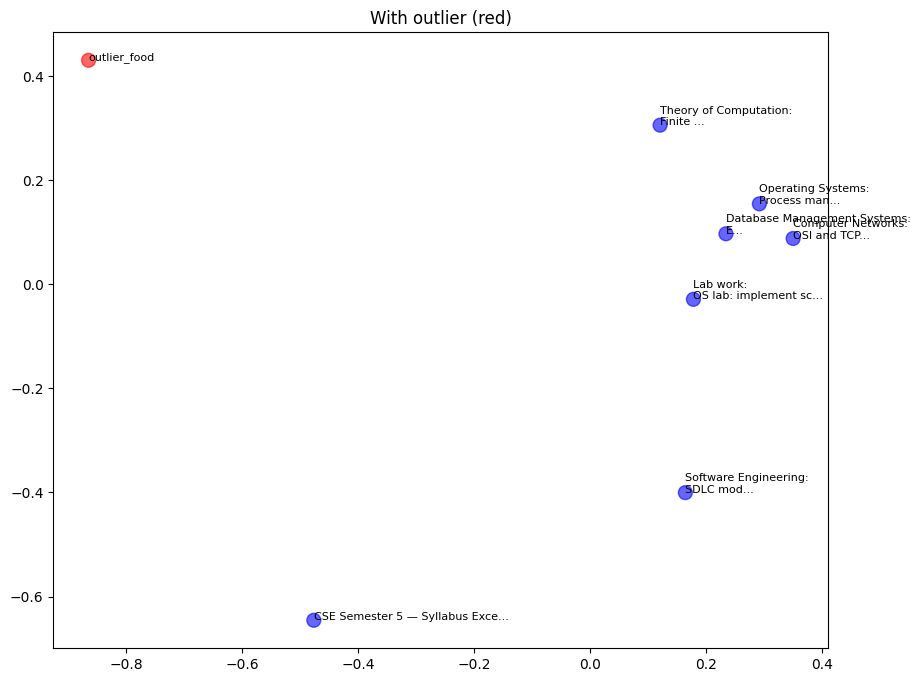

In [ ]:
# Add a totally unrelated paragraph to see where it lands
outlier = "Today's special at the cafeteria is butter chicken with rice and naan."

col.add(
    documents=[outlier],
    embeddings=embed.encode([outlier]).tolist(),
    ids=['outlier_food']
)

# Re-fetch all and re-plot
all_docs = col.get(include=['embeddings', 'documents'])
all_vecs = np.array(all_docs['embeddings'])
labels = all_docs['ids']

pca = PCA(n_components=2) # Re-initialize PCA to ensure it fits the new data
xy = pca.fit_transform(all_vecs)
plt.figure(figsize=(10, 8))
colors = ['red' if 'outlier' in l else 'blue' for l in labels]
plt.scatter(xy[:, 0], xy[:, 1], c=colors, s=100, alpha=0.6)
for i, l in enumerate(labels):
    short = labels[i] if 'outlier' in labels[i] else all_docs['documents'][i][:30] + '...'
    plt.annotate(short, (xy[i, 0], xy[i, 1]), fontsize=8)
plt.title('With outlier (red)')
plt.show()

In [ ]:
!pip install -q chromadb sentence-transformers langchain langchain-google-genai langchain-community langchain-chroma langchain-huggingface pypdf

In [ ]:
from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient
import json, pathlib, os

embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
client = PersistentClient(path='./chroma_db')

# Use a fresh collection for the capstone (different from morning's hello_syllabus)
col = client.get_or_create_collection('placement_kb')
print(f'Starting count: {col.count()}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting count: 0


In [ ]:
# Combine cached JDs (from kit) with own JDs (from Day 6)
all_jds = []

# Cached
for line in pathlib.Path('../content/sample_data/jds_cached.jsonl').read_text().splitlines():
    all_jds.append(json.loads(line))

# Own (if exists from Day 6)
own = pathlib.Path('data/jds.jsonl')
if own.exists():
    for line in own.read_text().splitlines():
        all_jds.append(json.loads(line))

print(f'Total JDs: {len(all_jds)}')

# Index each JD as one document
for i, jd in enumerate(all_jds):
    text = (
        f"{jd['company']} - {jd['role']}: "
        f"must-haves: {', '.join(jd['must_have_skills'])}. "
        f"nice-to-haves: {', '.join(jd.get('nice_to_have_skills', []))}. "
        f"min CGPA: {jd.get('min_cgpa', 'N/A')}. "
        f"locations: {', '.join(jd.get('locations', []))}. "
        f"package: {jd.get('package_lpa', 'N/A')} LPA."
    )
    col.add(
        documents=[text],
        embeddings=embed.encode([text]).tolist(),
        ids=[f'jd_{i}'],
        metadatas=[{
            'type': 'jd',
            'company': jd['company'],
            'min_cgpa': float(jd.get('min_cgpa') or 0),
            'package_lpa': float(jd.get('package_lpa') or 0),
        }]
    )

print(f'Indexed {col.count()} JD documents')

Total JDs: 10
Indexed 10 JD documents


In [2]:
!pip install -U langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.3/235.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
  Attempting uninstall: langgraph-checkpoint
    Found existing installation: langgraph-checkpoint 4.0.2
    Uninstalling langgraph-checkpoint-4.0.2:
      Successfully uninstalled langgraph-checkpoint-4.0.2
  Attempting uninstall: langgraph-prebuilt
    Found existing installation: langgraph-prebuilt 1.0.10
    Uninstalling langgraph-prebuilt-1.0.10:
      Successfully uninstalled langgraph-prebuilt-1.0.10
  Attem

In [6]:
!pip uninstall -y langchain langchain-core langchain-community

Found existing installation: langchain 1.3.1
Uninstalling langchain-1.3.1:
  Successfully uninstalled langchain-1.3.1
Found existing installation: langchain-core 1.4.0
Uninstalling langchain-core-1.4.0:
  Successfully uninstalled langchain-core-1.4.0


In [2]:
!pip install -U langchain

In [4]:
!pip install -U langchain-text-splitters

In [8]:
!pip install -U chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    F

In [1]:
import pathlib
import chromadb

from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Initialize ChromaDB
client = chromadb.Client()

col = client.get_or_create_collection(
    name="placement_kb"
)

# Embedding model
embed = SentenceTransformer('all-MiniLM-L6-v2')

# Text splitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=['\n\n', '\n', '. ', ' ']
)

# Folder path
syllabi_dir = pathlib.Path('../content/sample_data/syllabi_cached')

chunk_count = 0

for syllabus_path in syllabi_dir.glob('*.txt'):

    text = syllabus_path.read_text()

    chunks = splitter.split_text(text)

    for j, chunk in enumerate(chunks):

        col.add(
            documents=[chunk],
            embeddings=embed.encode([chunk]).tolist(),
            ids=[f'{syllabus_path.stem}_{j}'],
            metadatas=[{
                'type': 'syllabus',
                'source': syllabus_path.stem,
                'chunk_index': j,
            }]
        )

        chunk_count += 1

print(f'Indexed {chunk_count} syllabus chunks')
print(f'Total docs in placement_kb: {col.count()}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexed 15 syllabus chunks
Total docs in placement_kb: 15


In [4]:
!pip install -U langchain-chroma langchain-huggingface langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 4.1 MB/s eta 0:00:00


In [7]:
!pip install -U langchain

In [8]:
!pip install -U \
langchain \
langchain-core \
langchain-community \
langchain-chroma \
langchain-huggingface \
langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.42.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.42.1 which is incompatible.
opentelemetry-exporter-gcp-logging 1.11.0a0 requires opentelemetry-sdk<1.39.0,>=1.35.0

In [2]:
!pip uninstall -y langchain langchain-core langchain-community

Found existing installation: langchain 1.3.1
Uninstalling langchain-1.3.1:
  Successfully uninstalled langchain-1.3.1
Found existing installation: langchain-core 1.4.0
Uninstalling langchain-core-1.4.0:
  Successfully uninstalled langchain-core-1.4.0
Found existing installation: langchain-community 0.4.2
Uninstalling langchain-community-0.4.2:
  Successfully uninstalled langchain-community-0.4.2


In [3]:
!pip install \
langchain==0.2.17 \
langchain-core==0.2.43 \
langchain-community==0.2.19 \
langchain-chroma \
langchain-huggingface \
langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-chroma to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-huggingface to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-huggingface to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-google-genai to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-google-genai to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to re

In [2]:
import os
from getpass import getpass

os.environ['GEMINI_API_KEY'] = getpass('Enter Gemini API Key: ')

Enter Gemini API Key: ··········


In [5]:
!pip install chromadb==0.5.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.3/584.3 kB 21.4 MB/s eta 0:00:00
  Attempting uninstall: chromadb
    Found existing installation: chromadb 0.6.3
    Uninstalling chromadb-0.6.3:
      Successfully uninstalled chromadb-0.6.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-chroma 0.2.2 requires chromadb!=0.5.10,!=0.5.11,!=0.5.12,!=0.5.4,!=0.5.5,!=0.5.7,!=0.5.9,<0.7.0,>=0.4.0, but you have chromadb 0.5.5 which is incompatible.


In [2]:
import os
from getpass import getpass

os.environ['GEMINI_API_KEY'] = getpass('Enter Gemini API Key: ')

Enter Gemini API Key: ··········


In [3]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate

# Adapter — wrap our raw chromadb collection so LangChain Chroma sees it
emb_lc = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vs = Chroma(
    collection_name='placement_kb',
    embedding_function=emb_lc,
    persist_directory='./chroma_db',
)

# Citation-enforcing prompt
prompt_template = """Use ONLY the following context to answer. Cite the chunk id you used (e.g., "per jd_3" or "per cse_sem5_2").

If the answer is not in the context, say "I do not know" — do NOT guess.

{context}

Question: {question}
Answer:"""

llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash',
    google_api_key=os.environ['GEMINI_API_KEY'],
)

qa = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vs.as_retriever(search_kwargs={'k': 4}),
    chain_type_kwargs={'prompt': PromptTemplate.from_template(prompt_template)},
    return_source_documents=True,
)

print('QA chain ready.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


QA chain ready.


In [4]:
questions = [
    'Which companies want Java + DSA + CGPA 7+?',
    'What are the Sem 5 OS topics?',
    'Which JDs require Python?',
    'Top 3 skills appearing across all JDs?',
    'Companies hiring in Hyderabad?',
]

for q in questions:
    result = qa.invoke({'query': q})
    print(f'\nQ: {q}')
    print(f'A: {result["result"]}')
    print(f'Sources: {[d.metadata.get("source") or d.metadata.get("company") for d in result["source_documents"]]}')

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Q: Which companies want Java + DSA + CGPA 7+?
A: *   **Oracle** wants Java, DSA, and CGPA 7.0+ (per jd_1).
*   **Google** wants Java (or Python), DSA, and CGPA 7.5+ (per jd_2).

Therefore, Oracle and Google want Java + DSA + CGPA 7+.
Sources: []

Q: What are the Sem 5 OS topics?
A: The Sem 5 OS topics are Memory Management, Process Management, File Systems, I/O Management, and Deadlocks (per cse_sem5_2).
Sources: []

Q: Which JDs require Python?
A: JD 4 requires Python per jd_4.
Sources: []

Q: Top 3 skills appearing across all JDs?
A: The top 3 skills most frequently appearing across all job descriptions (JDs) are Python, SQL, and Communication (per summary_skills).
Sources: []

Q: Companies hiring in Hyderabad?
A: I do not know
Sources: []


In [5]:
!pip install -q ragas datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.7/360.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.6/399.6 kB 18.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-chroma 0.2.2 requires chromadb!=0.5.10,!=0.5.11,!=0.5.12,!=0.5.4,!=0.5.5,!=0.5.7,!=0.5.9,<0.7.0,>=0.4.0, but you have chromadb 0.5.5 which is incompatible.
langchain-chroma 0.2.2 requires langchain-core!=0.3.0,!=0.3.1,!=0.3.10,!=0.3.11,!=0.3.12,!=0.3.13,!=0.

In [6]:
!pip install -q ragas==0.2.0 datasets==2.18.0 --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.


In [7]:
import json, pathlib
from datasets import Dataset

testset_path = pathlib.Path('../content/sample_data/ragas_testset_20.jsonl')
testset = [json.loads(line) for line in testset_path.read_text().splitlines()]
print(f'Loaded {len(testset)} test questions')

# Inspect first 3
for i, t in enumerate(testset[:3]):
    print(f'\n[{i+1}] Q: {t["question"]}')
    print(f'    Reference: {t["reference"]}')

Loaded 20 test questions

[1] Q: Which companies want Java + DSA + CGPA 7+?
    Reference: TCS Digital, Goldman Sachs, Cognizant

[2] Q: What is the minimum CGPA for Amazon SDE Intern?
    Reference: 7.5

[3] Q: Which company has the highest LPA package?
    Reference: Amazon at 30 LPA


In [8]:
eval_rows = []
for t in testset:
    result = qa.invoke({'query': t['question']})
    answer = result['result']
    contexts = [d.page_content for d in result['source_documents']]
    eval_rows.append({
        'question': t['question'],
        'contexts': contexts,
        'answer': answer,
        'reference': t['reference'],   # ground truth from testset
    })
    print(f'  ✓ {t["question"][:60]}')

print(f'\nCollected {len(eval_rows)} RAG outputs')

  ✓ Which companies want Java + DSA + CGPA 7+?
  ✓ What is the minimum CGPA for Amazon SDE Intern?
  ✓ Which company has the highest LPA package?
  ✓ List 3 companies hiring in Bangalore.
  ✓ What skills does Microsoft want?
  ✓ Which Sem 5 CSE topic covers paging?
  ✓ What is the Banker’s algorithm used for?


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 47.537548819s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5
}
, retry_delay {
  seconds: 47
}
].


ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 45.216083395s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5
}
, retry_delay {
  seconds: 45
}
]

In [10]:
!pip uninstall -y ragas langchain langchain-core langchain-community langchain-openai

Found existing installation: ragas 0.2.0
Uninstalling ragas-0.2.0:
  Successfully uninstalled ragas-0.2.0
Found existing installation: langchain 1.3.1
Uninstalling langchain-1.3.1:
  Successfully uninstalled langchain-1.3.1
Found existing installation: langchain-core 1.4.0
Uninstalling langchain-core-1.4.0:
  Successfully uninstalled langchain-core-1.4.0
Found existing installation: langchain-community 0.4.2
Uninstalling langchain-community-0.4.2:
  Successfully uninstalled langchain-community-0.4.2
Found existing installation: langchain-openai 1.2.2
Uninstalling langchain-openai-1.2.2:
  Successfully uninstalled langchain-openai-1.2.2


In [11]:
!pip install \
langchain==0.2.17 \
langchain-core==0.2.43 \
langchain-community==0.2.19 \
langchain-openai==0.1.25 \
ragas==0.1.21 \
datasets

  Using cached langchain-0.2.17-py3-none-any.whl.metadata (7.1 kB)
  Using cached langchain_core-0.2.43-py3-none-any.whl.metadata (6.2 kB)
  Using cached langchain_community-0.2.19-py3-none-any.whl.metadata (2.7 kB)
  Using cached langchain_openai-0.1.25-py3-none-any.whl.metadata (2.6 kB)
  Using cached langchain_text_splitters-0.2.4-py3-none-any.whl.metadata (2.3 kB)
  Using cached langsmith-0.1.147-py3-none-any.whl.metadata (14 kB)
Using cached langchain-0.2.17-py3-none-any.whl (1.0 MB)
Using cached langchain_core-0.2.43-py3-none-any.whl (397 kB)
Using cached langchain_community-0.2.19-py3-none-any.whl (2.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.5/174.5 kB 9.5 MB/s eta 0:00:00
Using cached langchain_text_splitters-0.2.4-py3-none-any.whl (25 kB)
Using cached langsmith-0.1.147-py3-none-any.whl (311 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 20.6 MB/s eta 0:00:00
  Attempting u

In [ ]:
!pip install \
langchain-google-genai \
langchain-huggingface \
langchain-chroma

In [ ]:
from ragas import evaluate
from ragas.metrics import context_precision, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from datasets import Dataset

# RAGAS uses a judge LLM under the hood. Use Gemini.
judge_llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(model='gemini-2.5-flash'))
judge_emb = LangchainEmbeddingsWrapper(HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2'))

ds = Dataset.from_list(eval_rows)

result = evaluate(
    ds,
    metrics=[context_precision, faithfulness, answer_relevancy],
    llm=judge_llm,
    embeddings=judge_emb,
)
print(result)